# 13. Final Comparison

Ten models, all scored on the same held-out days (2023-01-01 to 2025-12-30). **Run notebooks
01–12 first** — this reads the JSON files they write to `models/results/`.

They do not all answer the same question, so they are not all in one ranked table. Three groups:

1. **Seven core models on the identical 37-feature set** — a like-for-like contest.
2. **Two variants that change the target or the objective** — the per-pollutant split and the
   tail-focused quantile model. Same features, different question.
3. **One model on a different feature set** — the enriched physics run. Best score in the
   project, but it is not comparable to the others in a ranked list because its inputs differ.

A single sorted table containing all ten would imply comparisons that are not valid.

## Setup

In [1]:
import sys, json
from pathlib import Path

_here = Path.cwd()
sys.path.insert(0, str(_here if _here.name == 'models' else _here / 'models'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from model_utils import load_split, load_all_results, metrics, RESULTS, PLOT_STYLE

X_train, y_train, X_test, y_test, meta = load_split()
yt = np.asarray(y_test, dtype=float)

CORE = ['Linear Regression', 'Random Forest', 'Gradient Boosting',
        'SVR', 'KNN', 'Neural Network', 'Ensemble']
VARIANTS  = ['Pollutant Split', 'Quantile GBR (q=0.8)']
DIFFERENT = ['Ensemble + Physics']

PALETTE = ['#005A8C', '#D55E00', '#009E73', '#8E4EC6', '#B07800', '#4C9BD1', '#B5174E']
COLOR = dict(zip(CORE, PALETTE))
COLOR.update({'Pollutant Split': '#7A6A53', 'Quantile GBR (q=0.8)': '#A8502F',
              'Ensemble + Physics': '#1F7A54'})
INK, MUTED = '#1a1a1a', '#6b6b6b'

results = load_all_results()
print(f'{len(results)} model results loaded')
print(f'test period: {meta["test_range"][0]} -> {meta["test_range"][1]} ({meta["n_test"]} days)')

10 model results loaded
test period: 2023-01-01 -> 2025-12-30 (1095 days)


## Reference baselines

R² of 0.79 sounds strong, but strong against what? Two trivial predictors set the floor. The
second one matters most: day-of-year climatology captures the seasonal cycle using **no weather
information at all**, so anything a weather model earns above that line is weather's real
contribution.

In [2]:
mean_pred = np.full(len(yt), y_train.mean())

train_doy = pd.DataFrame({'doy': meta['train_dates'].dt.dayofyear, 'aqi': y_train.values})
clim = (train_doy.groupby('doy')['aqi'].mean().reindex(range(1, 367))
        .interpolate().rolling(15, center=True, min_periods=1).mean())
clim_pred = meta['test_dates'].dt.dayofyear.map(clim).values

baselines = pd.DataFrame([
    {'baseline': 'training mean (constant)', **metrics(yt, mean_pred)},
    {'baseline': 'day-of-year climatology',  **metrics(yt, clim_pred)},
])
print(baselines.round(3).to_string(index=False))

                baseline   rmse    mae     r2   mape  within_10
training mean (constant) 40.422 33.230 -0.003 42.767     13.881
 day-of-year climatology 31.764 24.507  0.381 31.331     28.676


## Group 1 — the seven core models

Identical features, identical split, identical tuning protocol. This is the only fully
like-for-like comparison in the project.

In [3]:
core = results[results.Model.isin(CORE)].copy().sort_values('Test RMSE').reset_index(drop=True)
cols = ['Model', 'Test RMSE', 'Test MAE', 'Test R2', 'Test MAPE %',
        'Within 10 AQI %', 'Train RMSE', 'Overfit Gap']
print(core[cols].round(3).to_string(index=False))
print()
print(f'climatology baseline (no weather): RMSE {metrics(yt, clim_pred)["rmse"]:.2f}, '
      f'R2 {metrics(yt, clim_pred)["r2"]:.3f}')

            Model  Test RMSE  Test MAE  Test R2  Test MAPE %  Within 10 AQI %  Train RMSE  Overfit Gap
         Ensemble     18.336    12.949    0.794       14.778           53.790      12.400        5.936
              SVR     18.851    13.565    0.782       15.822           48.950      17.246        1.605
   Neural Network     19.054    13.992    0.777       16.629           48.493      16.893        2.161
Gradient Boosting     19.484    13.842    0.767       15.818           50.137       8.735       10.749
    Random Forest     20.275    14.674    0.748       17.200           47.489       8.763       11.512
              KNN     21.887    15.712    0.706       18.684           45.662       0.000       21.887
Linear Regression     24.007    17.879    0.646       21.067           38.265      24.551       -0.544

climatology baseline (no weather): RMSE 31.76, R2 0.381


**KNN's Train RMSE of 0.000 and its Overfit Gap are artifacts**, not results. It was tuned to
`weights='distance'`, so a training point is its own nearest neighbour at distance zero and the
model reproduces every training label by construction. Read only its test columns.

## How much of this ranking is real?

A ranked table invites you to read the order as meaningful. With 1,095 test days it mostly is not.

Two different questions get asked below, with very different precision:

- **How precise is one model's RMSE?** Bootstrap it alone — intervals come out ~±1.3 points wide,
  because resampling days changes which hard days are included.
- **Is model A better than model B?** Resample the *same* days for both and take the difference.
  Most of the day-to-day variation is shared and cancels, so this resolves far smaller gaps.

In [4]:
rng = np.random.default_rng(0)
n = len(yt)
boot_idx = [rng.integers(0, n, n) for _ in range(5000)]

def load_pred(name):
    return np.load(RESULTS / f'{name.lower().replace(" ", "_")}_test_pred.npy')

preds = {m: load_pred(m) for m in results.Model}

def rmse_of(y, p):
    return float(np.sqrt(((y - p) ** 2).mean()))

ci_rows = []
for m in core.Model:
    vals = np.array([rmse_of(yt[i], preds[m][i]) for i in boot_idx])
    lo, hi = np.percentile(vals, [2.5, 97.5])
    ci_rows.append({'Model': m, 'Test RMSE': rmse_of(yt, preds[m]),
                    'CI low': lo, 'CI high': hi, 'CI width': hi - lo})
print('Single-model RMSE, 95% bootstrap CI:')
print(pd.DataFrame(ci_rows).round(2).to_string(index=False))

Single-model RMSE, 95% bootstrap CI:
            Model  Test RMSE  CI low  CI high  CI width
         Ensemble      18.34   17.04    19.67      2.62
              SVR      18.85   17.59    20.12      2.53
   Neural Network      19.05   17.83    20.36      2.53
Gradient Boosting      19.48   18.15    20.81      2.66
    Random Forest      20.27   18.95    21.59      2.64
              KNN      21.89   20.48    23.26      2.78
Linear Regression      24.01   22.67    25.34      2.67


**A row-count caveat before going further.** The physics model is scored on **1,089** test
days, not 1,095 — joining the trapping variables dropped a handful of dates, and three more went
to the lag warm-up. Its RMSE is therefore *not* directly comparable to the 18.336 quoted for the
plain ensemble on 1,095 days.

Notebook 09 handled this correctly by re-fitting the base ensemble on the identical 1,089 rows,
giving **18.499 → 16.911** as the like-for-like comparison. Everything below aligns predictions on
date so the same caveat cannot creep back in.

In [5]:
# align every model's predictions to a common date index
v2 = pd.read_csv(Path(_here if _here.name == 'models' else _here / 'models').parent
                 / 'data' / 'processed' / 'la_modeling_dataset_v2.csv', parse_dates=['date'])
split_date = pd.Timestamp(meta['split_date'])
phys_dates = v2[v2.date >= split_date]['date'].reset_index(drop=True)

test_dates = pd.DatetimeIndex(meta['test_dates'])
aligned = {m: pd.Series(preds[m], index=test_dates) for m in results.Model
           if m != 'Ensemble + Physics'}
aligned['Ensemble + Physics'] = pd.Series(preds['Ensemble + Physics'],
                                          index=pd.DatetimeIndex(phys_dates))
truth = pd.Series(yt, index=test_dates)

common = truth.index
for s in aligned.values():
    common = common.intersection(s.index)
print(f'full test set: {len(truth)} days')
print(f'physics model: {len(aligned["Ensemble + Physics"])} days')
print(f'common to all: {len(common)} days  -> used for any chart comparing across groups')

truth_c = truth.loc[common]
aligned_c = {m: s.loc[common] for m, s in aligned.items()}
ytc = truth_c.values

full test set: 1095 days
physics model: 1089 days
common to all: 1089 days  -> used for any chart comparing across groups


In [6]:
leader = core.Model.iloc[0]
print(f'Paired comparisons against the leader ({leader}):\n')
print(f'{"challenger":24} {"dRMSE":>7}   {"95% CI":>18}   {"P(leader better)":>16}')
for m in core.Model[1:]:
    d = np.array([rmse_of(yt[i], preds[leader][i]) - rmse_of(yt[i], preds[m][i]) for i in boot_idx])
    lo, hi = np.percentile(d, [2.5, 97.5])
    print(f'{m:24} {d.mean():+7.3f}   [{lo:+.3f}, {hi:+.3f}]   {(d < 0).mean():>16.3f}')

print('\nThe comparison that started all this — SVR vs the neural network:')
d = np.array([rmse_of(yt[i], preds['SVR'][i]) - rmse_of(yt[i], preds['Neural Network'][i])
              for i in boot_idx])
lo, hi = np.percentile(d, [2.5, 97.5])
print(f'  dRMSE {d.mean():+.3f}   95% CI [{lo:+.3f}, {hi:+.3f}]   P(SVR better) {(d < 0).mean():.3f}')
print('  -> interval straddles zero: that ranking was never a real finding.')

Paired comparisons against the leader (Ensemble):

challenger                 dRMSE               95% CI   P(leader better)
SVR                       -0.520   [-0.887, -0.162]              0.997
Neural Network            -0.722   [-1.103, -0.341]              1.000
Gradient Boosting         -1.143   [-1.488, -0.807]              1.000


Random Forest             -1.935   [-2.411, -1.473]              1.000


KNN                       -3.551   [-4.283, -2.805]              1.000
Linear Regression         -5.669   [-6.655, -4.721]              1.000

The comparison that started all this — SVR vs the neural network:
  dRMSE -0.202   95% CI [-0.647, +0.250]   P(SVR better) 0.803
  -> interval straddles zero: that ranking was never a real finding.


**Never compare two models by checking whether their individual confidence intervals overlap.**
Those intervals span more than a point each and overlap almost completely, yet the paired test
resolves the ensemble's advantage clearly. The overlap test is far too conservative because it
throws away the fact that both models are being scored on the same days.

## Group 2 and 3 — the variants

These change something other than the model, so they belong in their own table with the change
named explicitly.

In [7]:
def row_for(name, note):
    r = results[results.Model == name].iloc[0]
    return {'Model': name, 'what changed': note,
            'Test RMSE': r['Test RMSE'], 'Test MAE': r['Test MAE'],
            'Test R2': r['Test R2'], 'Within 10 AQI %': r['Within 10 AQI %'],
            'n days': int(r.get('n_days', len(truth)))}

ext = pd.DataFrame([
    row_for('Ensemble', 'reference: 37 features, direct target'),
    row_for('Pollutant Split', 'target split by pollutant, max of predictions'),
    row_for('Quantile GBR (q=0.8)', 'objective: 80th percentile, not the mean'),
    row_for('Ensemble + Physics', 'FEATURES: +24 MERRA-2 trapping variables'),
])
ext.loc[ext.Model == 'Ensemble + Physics', 'n days'] = len(aligned['Ensemble + Physics'])
print(ext.round(3).to_string(index=False))

print('\nRe-scored on the 1,089 days all four share, so the comparison is like-for-like:')
rows = []
for m in ['Ensemble', 'Pollutant Split', 'Quantile GBR (q=0.8)', 'Ensemble + Physics']:
    rows.append({'Model': m, **metrics(ytc, aligned_c[m].values)})
print(pd.DataFrame(rows).round(3).to_string(index=False))

hi_c = ytc > 150
print(f'\nExtreme-day behaviour on the common days (AQI > 150, n={int(hi_c.sum())}):')
for m in ['Ensemble', 'Pollutant Split', 'Quantile GBR (q=0.8)', 'Ensemble + Physics']:
    p = aligned_c[m].values
    print(f'  {m:24} MAE {np.mean(np.abs(ytc[hi_c]-p[hi_c])):6.2f}   '
          f'bias {np.mean(p[hi_c]-ytc[hi_c]):+7.2f}   '
          f'recall {np.mean(p[hi_c] > 150)*100:5.1f}%')

               Model                                  what changed  Test RMSE  Test MAE  Test R2  Within 10 AQI %  n days
            Ensemble         reference: 37 features, direct target     18.336    12.949    0.794           53.790    1095
     Pollutant Split target split by pollutant, max of predictions     18.531    12.877    0.789           55.799    1095
Quantile GBR (q=0.8)      objective: 80th percentile, not the mean     20.690    15.701    0.737           41.553    1095
  Ensemble + Physics      FEATURES: +24 MERRA-2 trapping variables     16.911    11.925    0.825           56.474    1089

Re-scored on the 1,089 days all four share, so the comparison is like-for-like:
               Model   rmse    mae    r2   mape  within_10
            Ensemble 18.315 12.943 0.795 14.776     53.719
     Pollutant Split 18.503 12.863 0.791 14.083     55.831
Quantile GBR (q=0.8) 20.701 15.715 0.738 20.569     41.414
  Ensemble + Physics 16.911 11.925 0.825 13.810     56.474

Extreme-day b

## Ranking chart

Core models in their own colours, variants in muted tones, and the physics run flagged as using a
different feature set.

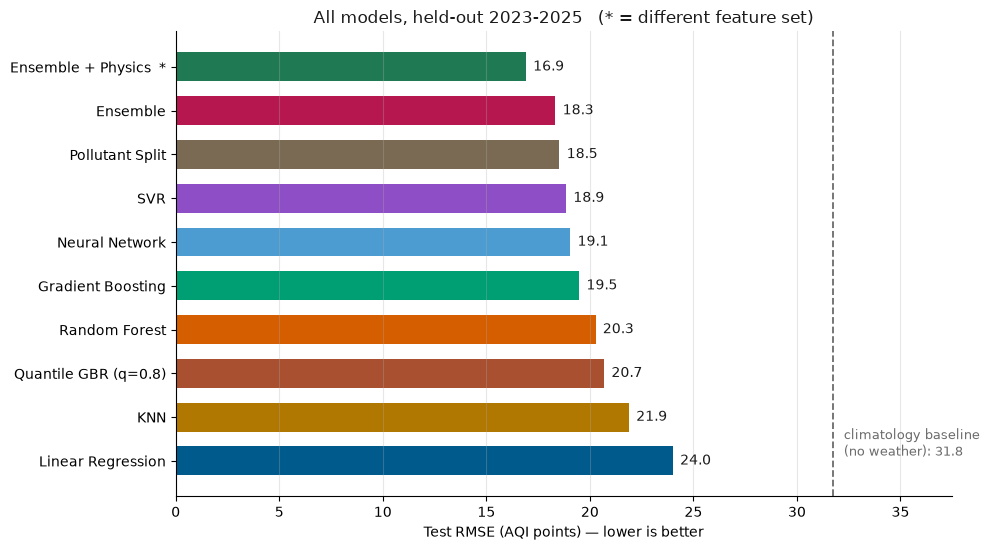

In [8]:
with plt.rc_context(PLOT_STYLE):
    fig, ax = plt.subplots(figsize=(10, 5.6))
    plot_df = results.sort_values('Test RMSE', ascending=False)
    clim_rmse = metrics(yt, clim_pred)['rmse']

    labels = [m + ('  *' if m in DIFFERENT else '') for m in plot_df.Model]
    bars = ax.barh(labels, plot_df['Test RMSE'],
                   color=[COLOR[m] for m in plot_df.Model], height=0.66)
    for bar, val in zip(bars, plot_df['Test RMSE']):
        ax.text(val + 0.35, bar.get_y() + bar.get_height() / 2, f'{val:.1f}',
                va='center', fontsize=10, color=INK)

    ax.set_xlim(0, max(plot_df['Test RMSE'].max(), clim_rmse) * 1.18)
    ax.axvline(clim_rmse, color=MUTED, ls='--', lw=1.3)
    ax.text(clim_rmse + 0.5, 0.4, f'climatology baseline\n(no weather): {clim_rmse:.1f}',
            ha='left', va='center', fontsize=9, color=MUTED)
    ax.set_xlabel('Test RMSE (AQI points) — lower is better')
    ax.set_title('All models, held-out 2023-2025   (* = different feature set)',
                 fontsize=12, color=INK)
    ax.grid(axis='y', visible=False)
    plt.tight_layout(); plt.show()

## Where the errors are

Aggregate RMSE hides what matters most for air quality: a model can look excellent while being
useless precisely on the days that trigger health advisories.

Mean absolute error by band (common 1,089 days):
band                  Good\n0-50  Moderate\n51-100  USG\n101-150  Unhealthy\n151+
Model                                                                            
Linear Regression          10.90             14.22         16.10            47.58
Random Forest              10.90             10.62         17.40            35.80
SVR                         9.55              9.88         16.92            31.97
Ensemble                    7.48              9.50         17.09            30.27
Quantile GBR (q=0.8)       13.44             14.84         16.18            21.96
Ensemble + Physics          7.40              9.00         16.67            24.60


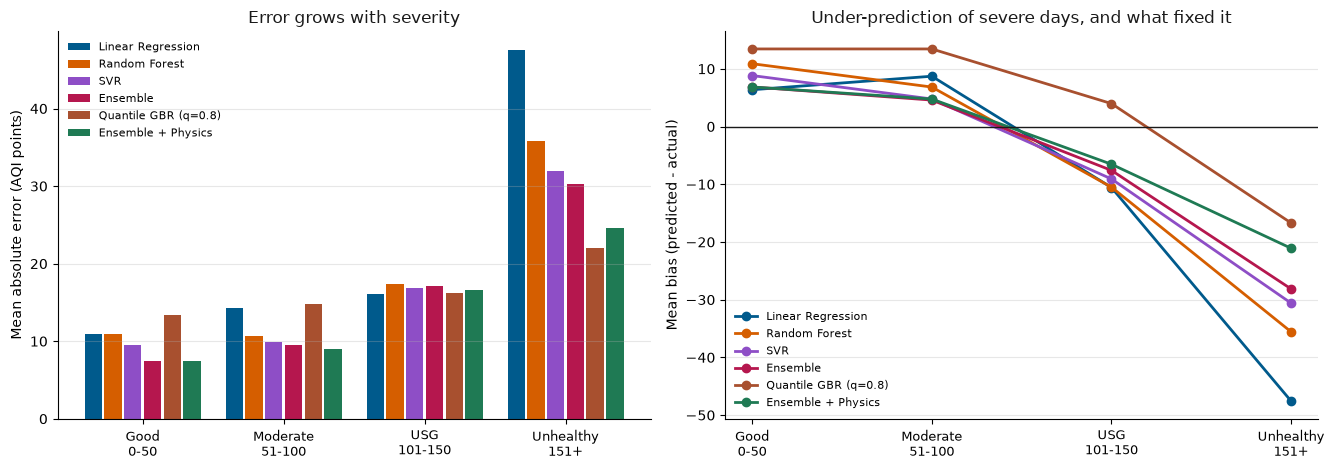

In [9]:
BANDS = [(0, 50, 'Good\n0-50'), (50, 100, 'Moderate\n51-100'),
         (100, 150, 'USG\n101-150'), (150, 300, 'Unhealthy\n151+')]
SHOW = ['Linear Regression', 'Random Forest', 'SVR', 'Ensemble',
        'Quantile GBR (q=0.8)', 'Ensemble + Physics']

rows = []
for lo, hi, label in BANDS:
    m = (ytc > lo) & (ytc <= hi)
    for name in SHOW:
        rows.append({'band': label, 'n': int(m.sum()), 'Model': name,
                     'mae': np.mean(np.abs(ytc[m] - aligned_c[name].values[m])),
                     'bias': np.mean(aligned_c[name].values[m] - ytc[m])})
band = pd.DataFrame(rows)
print('Mean absolute error by band (common 1,089 days):')
print(band.pivot(index='Model', columns='band', values='mae')
        .reindex(SHOW)[[b[2] for b in BANDS]].round(2).to_string())

with plt.rc_context(PLOT_STYLE):
    fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))
    labels = [b[2] for b in BANDS]
    x = np.arange(len(labels)); w = 0.14
    for i, name in enumerate(SHOW):
        sub = band[band.Model == name].set_index('band').reindex(labels)
        axes[0].bar(x + (i - 2.5) * w, sub['mae'], w * 0.88, color=COLOR[name], label=name)
        axes[1].plot(x, sub['bias'], 'o-', color=COLOR[name], label=name, lw=2, ms=6)
    axes[0].set_xticks(x); axes[0].set_xticklabels(labels, fontsize=9)
    axes[0].set_ylabel('Mean absolute error (AQI points)')
    axes[0].set_title('Error grows with severity', fontsize=12, color=INK)
    axes[0].legend(frameon=False, fontsize=8); axes[0].grid(axis='x', visible=False)
    axes[1].axhline(0, color=INK, lw=1)
    axes[1].set_xticks(x); axes[1].set_xticklabels(labels, fontsize=9)
    axes[1].set_ylabel('Mean bias (predicted - actual)')
    axes[1].set_title('Under-prediction of severe days, and what fixed it', fontsize=12, color=INK)
    axes[1].legend(frameon=False, fontsize=8); axes[1].grid(axis='x', visible=False)
    plt.tight_layout(); plt.show()

## Verdict

**Best model: the stacked ensemble on the enriched feature set — test RMSE 16.91, R² 0.825.**

Among models sharing the original 37 features, the stacked ensemble of SVR + MLP + Gradient
Boosting wins at 18.34, and its advantage over each individual member is statistically resolvable.
The ordering *among* the individual models is not: SVR beat the neural network by 0.203 RMSE with
a 95% interval of [−0.65, +0.25], and rolling-origin validation (notebook 11) confirmed it
directly — four different models win at least one of six annual folds.

Ranked by what actually moved the needle:

| change | RMSE | gain | what bought it |
|---|---:|---:|---|
| Linear regression baseline | 24.01 | — | — |
| Best single model (SVR) | 18.85 | **−5.16** | nonlinearity |
| Stacked ensemble | 18.34 | −0.51 | combining models |
| **Ensemble + trapping physics** | **16.91** | **−1.40** | better features |

(The physics row is measured on the 1,089 common days, where the plain ensemble scores 18.315.
Notebook 09's stricter ablation — refitting the baseline on exactly the enriched rows, train and
test — puts the gain at 1.588, CI [−2.279, −0.918]. Either way it is the largest single
improvement in the project.)

**Features beat model choice, by roughly three to one.** Going from a linear model to a good
nonlinear one was worth 5.2 RMSE points. Every subsequent refinement of the *modelling* —
tuning, ensembling, target splitting — bought about 0.5 points between them. Adding four
atmospheric variables bought 1.4–1.6. For a project of this size that is the central lesson.

### What we learned about LA's air

1. **Upper-air temperature beats surface temperature.** `t850_mean` correlates 0.753 with daily
   AQI against `t2m_max`'s 0.705, and permutation importance ranks it first by a factor of 3.5.
   It is a cleaner measure of the air mass, uncontaminated by the marine layer.
2. **Ozone and PM2.5 are different problems.** Fitted separately, ozone reaches R² 0.870 and PM2.5
   only 0.418. The headline "weather explains 79% of AQI" averages a pollutant weather explains
   very well and one it barely explains at all.
3. **PM2.5's unexplained variance is not meteorological.** Better weather features improved ozone
   RMSE by 2.69 and PM2.5 by 0.20. Smoke, wood burning and cooking are not in any atmospheric
   variable, and no amount of MERRA-2 will recover them.
4. **Half the headline R² is just the calendar.** Day-of-year climatology, using no weather at all,
   reaches R² 0.381.
5. **The models still under-predict unhealthy days**, though the physics features cut that bias
   from −29 to −21. The residue is genuine regression to the mean, and quantile regression is the
   tool for it — q=0.9 catches 76% of unhealthy days instead of 47%, at the cost of overall accuracy.

### If this were deployed

**Two models, not one.** The enriched ensemble answers "what will the AQI be" (RMSE 16.9). A
quantile model answers "should we issue a warning" (76% recall on unhealthy days). No single
predictor serves both, and choosing the quantile level is a policy decision about false alarms
versus missed alerts, not a statistical one.

The 2026 forward test (notebook 12) is the evidence this generalizes: trained through 2025-12-30
and scored on 151 days that did not exist when the project was written, it held season-matched RMSE
within ~1.1 points of its retrospective performance.

### What is left

- **Prune the feature set.** `pblh_min` and its lags correlate with AQI at about −0.02 and are
  dead weight; the overfit gap widened from +5.9 to +7.6 when the feature count went to 61.
- **Bring in a smoke indicator.** NOAA HMS plume data is the obvious non-weather input, and it
  targets the one thing weather provably cannot explain.
- **Re-run the 2026 test after summer.** The current forward test is cool-season only, which is the
  easy half of the year.
- **Refit everything on the enriched features.** Notebooks 01–08 all use the 37-feature set; only
  the ensemble has been rerun with the physics variables.